In [1]:
import pandas as pd
import sqlite3

# connect (creates the file if it doesn't exist)
conn = sqlite3.connect("../data/olist.db")

# map: csv filename -> table name
tables = {
    "olist_customers_dataset.csv": "customers",
    "olist_orders_dataset.csv": "orders",
    "olist_order_items_dataset.csv": "order_items",
    "olist_order_payments_dataset.csv": "payments",
    "olist_order_reviews_dataset.csv": "reviews",
    "olist_products_dataset.csv": "products",
}

for csv_file, table_name in tables.items():
    df = pd.read_csv(f"../data/{csv_file}")
    df.to_sql(table_name, conn, if_exists="replace", index=False)
    print(f"Loaded {table_name}: {df.shape}")

conn.close()

Loaded customers: (99441, 5)
Loaded orders: (99441, 8)
Loaded order_items: (112650, 7)
Loaded payments: (103886, 5)
Loaded reviews: (99224, 7)
Loaded products: (32951, 9)


In [5]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("../data/olist.db")

# read each .sql file and run it
def run_sql_file(path, conn):
    with open(path, "r") as f:
        query = f.read()
    return pd.read_sql_query(query, conn)

rfm_base = run_sql_file("../sql/02_customer_rfm_base.sql", conn)
monthly_revenue = run_sql_file("../sql/03_monthly_revenue.sql", conn)

conn.close()

# check it worked
print(rfm_base.shape)
rfm_base.head()

(96478, 5)


,customer_id,last_purchase_date,frequency,monetary,recency_days
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,1,114.74,337.056852
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,1,67.41,458.326227
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,1,195.42,596.266377
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,1,179.35,427.181227
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,1,107.01,198.158345


In [6]:
rfm_base.to_csv("../outputs/rfm_base.csv", index=False)
monthly_revenue.to_csv("../outputs/monthly_revenue.csv", index=False)

In [7]:
print(os.listdir("../Outputs"))

['monthly_revenue.csv', 'rfm_base.csv']


In [8]:
import numpy as np

df = pd.read_csv("../Outputs/rfm_base.csv")

# Score 1-5 on each dimension using quintiles
df["R_score"] = pd.qcut(df["recency_days"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
df["F_score"] = pd.qcut(df["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
df["M_score"] = pd.qcut(df["monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

df["RFM_score"] = df["R_score"].astype(str) + df["F_score"].astype(str) + df["M_score"].astype(str)
df["RFM_total"] = df["R_score"] + df["F_score"] + df["M_score"]

def segment_customer(row):
    r, f, m = row["R_score"], row["F_score"], row["M_score"]
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 3 and f >= 3:
        return "Loyal Customers"
    elif r >= 4 and f <= 2:
        return "New Customers"
    elif r <= 2 and f >= 3:
        return "At Risk"
    elif r <= 2 and f <= 2 and m <= 2:
        return "Lost"
    else:
        return "Needs Attention"

df["segment"] = df.apply(segment_customer, axis=1)

print(df["segment"].value_counts())
df.head()

segment
Loyal Customers    28280
At Risk            23270
Needs Attention    16746
New Customers      15535
Champions           6337
Lost                6310
Name: count, dtype: int64


,customer_id,last_purchase_date,frequency,monetary,recency_days,R_score,F_score,M_score,RFM_score,RFM_total,segment
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,1,114.74,337.056852,2,1,3,213,6,Needs Attention
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,1,67.41,458.326227,1,1,2,112,4,Lost
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,1,195.42,596.266377,1,1,4,114,6,Needs Attention
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,1,179.35,427.181227,2,1,4,214,7,Needs Attention
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,1,107.01,198.158345,4,1,3,413,8,New Customers


In [9]:
df.to_csv("../Outputs/rfm_segmented.csv", index=False)
print(os.listdir("../Outputs"))

['monthly_revenue.csv', 'rfm_base.csv', 'rfm_segmented.csv']


In [10]:
orders_raw = pd.read_sql_query("""
    SELECT o.customer_id, o.order_purchase_timestamp
    FROM orders o
    WHERE o.order_status = 'delivered'
""", sqlite3.connect("../Data/olist.db"))

orders_raw["order_purchase_timestamp"] = pd.to_datetime(orders_raw["order_purchase_timestamp"])
orders_raw["order_month"] = orders_raw["order_purchase_timestamp"].dt.to_period("M")

# first purchase month per customer = their cohort
orders_raw["cohort_month"] = orders_raw.groupby("customer_id")["order_month"].transform("min")

# how many months after their first purchase is this order?
orders_raw["cohort_index"] = (
    (orders_raw["order_month"].dt.year - orders_raw["cohort_month"].dt.year) * 12
    + (orders_raw["order_month"].dt.month - orders_raw["cohort_month"].dt.month)
)

cohort_data = orders_raw.groupby(["cohort_month", "cohort_index"])["customer_id"].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index="cohort_month", columns="cohort_index", values="customer_id")

cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0).round(3)

retention.to_csv("../Outputs/cohort_retention.csv")
retention.head()

cohort_index,0
cohort_month,
2016-09,1.0
2016-10,1.0
2016-12,1.0
2017-01,1.0
2017-02,1.0


In [11]:
print(retention.shape)
print(retention.columns.tolist())
retention

(23, 1)
[0]


cohort_index,0
cohort_month,
2016-09,1.0
2016-10,1.0
2016-12,1.0
2017-01,1.0
2017-02,1.0
2017-03,1.0
2017-04,1.0
2017-05,1.0
2017-06,1.0


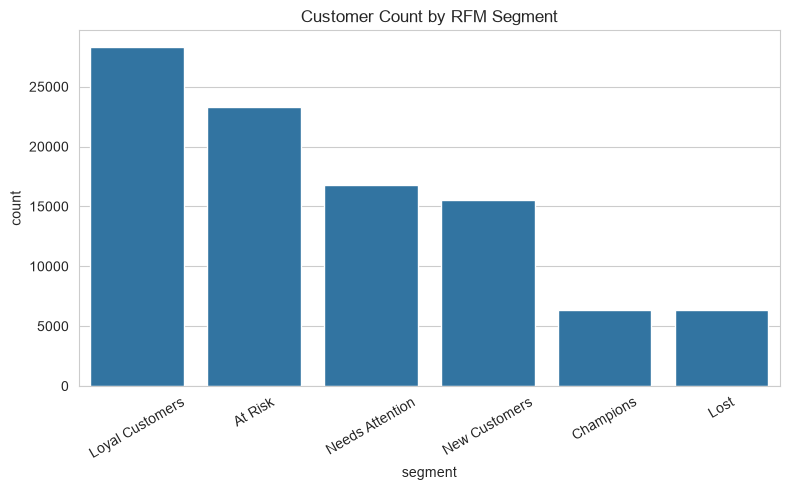

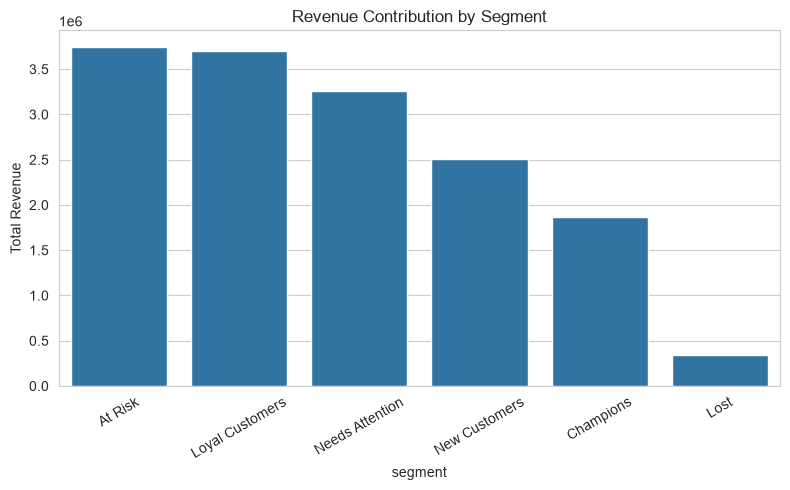

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
df = pd.read_csv("../outputs/rfm_segmented.csv")

# 1. Segment size
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="segment", order=df["segment"].value_counts().index)
plt.xticks(rotation=30)
plt.title("Customer Count by RFM Segment")
plt.tight_layout()
plt.savefig("../outputs/segment_counts.png", dpi=150)
plt.show()

# 2. Revenue contribution by segment
revenue_by_segment = df.groupby("segment")["monetary"].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=revenue_by_segment.index, y=revenue_by_segment.values)
plt.xticks(rotation=30)
plt.ylabel("Total Revenue")
plt.title("Revenue Contribution by Segment")
plt.tight_layout()
plt.savefig("../outputs/revenue_by_segment.png", dpi=150)
plt.show()



In [14]:
print(os.listdir("../Outputs"))

['cohort_heatmap.png', 'cohort_retention.csv', 'monthly_revenue.csv', 'revenue_by_segment.png', 'rfm_base.csv', 'rfm_segmented.csv', 'segment_counts.png']
